In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

In [2]:
daily = pd.read_excel("/content/daily_covers.xlsx")
res = pd.read_excel("/content/reservations.xlsx")

print("Daily shape:", daily.shape)
print("Reservations shape:", res.shape)

daily.head()

Daily shape: (626, 10)
Reservations shape: (37891, 7)


,date,covers_count,checks_count,avg_check,food_sales,beverage_sales,gross_sales,is_complete,anomaly_flag,notes
0,2022-01-01,206,77,79.45,8814.52,7755.14,16613.73,True,NaN,NaN
1,2022-01-02,170,57,72.86,6275.01,5658.69,11853.41,True,NaN,NaN
2,2022-01-04,78,22,86.43,3993.92,2831.38,6793.52,True,NaN,NaN
3,2022-01-05,94,35,75.32,4264.62,2609.28,6944.48,True,NaN,NaN
4,2022-01-06,99,38,84.60,4425.16,3613.01,8006.55,True,NaN,NaN


In [3]:

daily.info()
daily.describe()

res.info()
res.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            626 non-null    object 
 1   covers_count    626 non-null    int64  
 2   checks_count    626 non-null    int64  
 3   avg_check       626 non-null    float64
 4   food_sales      626 non-null    float64
 5   beverage_sales  626 non-null    float64
 6   gross_sales     626 non-null    float64
 7   is_complete     626 non-null    bool   
 8   anomaly_flag    10 non-null     object 
 9   notes           10 non-null     object 
dtypes: bool(1), float64(4), int64(2), object(3)
memory usage: 44.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37891 entries, 0 to 37890
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reservation_id  37891 non-null  object
 1   date            37891 non-null  object

,party_size
count,37891.000000
mean,3.153862
std,1.277379
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,6.000000


In [4]:
# cheking missing value
print("Daily Missing:\n", daily.isnull().sum())
print("Reservations Missing:\n", res.isnull().sum())

Daily Missing:
 date                0
covers_count        0
checks_count        0
avg_check           0
food_sales          0
beverage_sales      0
gross_sales         0
is_complete         0
anomaly_flag      616
notes             616
dtype: int64
Reservations Missing:
 reservation_id       0
date                 0
party_size           0
status               0
arrival_time      1525
booked_at          764
is_vip               0
dtype: int64


In [7]:
print(res.columns)

Index(['reservation_id', 'date', 'party_size', 'status', 'arrival_time',
       'booked_at', 'is_vip'],
      dtype='object')


In [5]:
# data cleaning
# Convert date
daily['date'] = pd.to_datetime(daily['date'])

# Remove incomplete days
if 'completeness_flag' in daily.columns:
    daily = daily[daily['completeness_flag'] == 1]

# Remove invalid targets
daily = daily[(daily['covers_count'] > 0)]
daily = daily[(daily['avg_check'] > 1) & (daily['avg_check'] < 1000)]

print("Cleaned daily shape:", daily.shape)

Cleaned daily shape: (620, 10)


In [8]:
# --- Clean & Prepare Reservations Data ---

# Convert timestamps safely
res['arrival_time'] = pd.to_datetime(
    res['arrival_time'],
    errors='coerce',
    infer_datetime_format=True
)

res['booked_at'] = pd.to_datetime(
    res['booked_at'],
    errors='coerce',
    infer_datetime_format=True
)

# Drop rows where arrival_time is invalid
res = res.dropna(subset=['arrival_time'])

# Normalize status and filter valid visits
if 'status' in res.columns:
    res['status'] = res['status'].str.lower()
    res = res[res['status'].isin(['completed', 'seated'])]

# Remove invalid party sizes
res = res[res['party_size'] > 0]

# Create lead time feature (advanced feature 🔥)
res['lead_time_hours'] = (
    res['arrival_time'] - res['booked_at']
).dt.total_seconds() / 3600

print("Cleaned reservations shape:", res.shape)

Cleaned reservations shape: (0, 8)


/tmp/ipykernel_3052/783995344.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  res['arrival_time'] = pd.to_datetime(
/tmp/ipykernel_3052/783995344.py:10: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  res['booked_at'] = pd.to_datetime(
/tmp/ipykernel_3052/783995344.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [9]:
# Create date from arrival_time
res['date'] = res['arrival_time'].dt.date

# Aggregate (FINAL VERSION)
agg_res = res.groupby('date').agg({
    'party_size': ['sum', 'mean'],
    'reservation_id': 'count',
    'is_vip': 'sum',
    'lead_time_hours': 'mean'
}).reset_index()

agg_res.columns = [
    'date',
    'total_reserved',
    'avg_party_size',
    'num_reservations',
    'vip_count',
    'avg_lead_time'
]

In [10]:
daily['date'] = pd.to_datetime(daily['date']).dt.date

df = daily.merge(agg_res, on='date', how='left')

# Fill missing reservation days (important!)
df.fillna(0, inplace=True)

In [11]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week

df['is_weekend'] = df['day_of_week'].isin([5,6]).astype(int)

In [12]:
df = df.sort_values('date')

# Lag features
df['lag_1'] = df['covers_count'].shift(1)
df['lag_7'] = df['covers_count'].shift(7)

# Rolling features
df['rolling_7'] = df['covers_count'].rolling(7).mean()
df['rolling_14'] = df['covers_count'].rolling(14).mean()

In [13]:
df = df.dropna()

In [14]:
baseline_map = df.groupby('day_of_week')['covers_count'].mean()
df['baseline_pred'] = df['day_of_week'].map(baseline_map)

In [15]:
split_index = int(len(df) * 0.8)

train = df.iloc[:split_index]
test = df.iloc[split_index:]

In [17]:
# --- DROP UNWANTED COLUMNS ---
drop_cols = ['covers_count', 'avg_check', 'date', 'anomaly_flag', 'notes']

X = df.drop(columns=drop_cols, errors='ignore')

# --- KEEP ONLY NUMERIC (CRITICAL FIX 🔥) ---
X = X.select_dtypes(include=[np.number])

# --- TARGET ---
y = df['covers_count']

# --- TRAIN TEST SPLIT (TIME BASED) ---
X_train = X.iloc[:len(train)]
X_test = X.iloc[len(train):]

y_train = y.iloc[:len(train)]
y_test = y.iloc[len(train):]

# --- MODEL ---
model = XGBRegressor(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

In [18]:
def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

mae = np.mean(np.abs(y_test - preds))
wmape_val = wmape(y_test, preds)
bias = np.mean(preds - y_test)

print("Model Performance")
print("MAE:", mae)
print("WMAPE:", wmape_val)
print("Bias:", bias)

Model Performance
MAE: 12.060364230734404
WMAPE: 0.07015851784043473
Bias: -1.7454187752770596


In [19]:
baseline_preds = test['baseline_pred']

print("\nBaseline Performance")
print("MAE:", np.mean(np.abs(y_test - baseline_preds)))
print("WMAPE:", wmape(y_test, baseline_preds))


Baseline Performance
MAE: 22.247550976891322
WMAPE: 0.12942023742040537


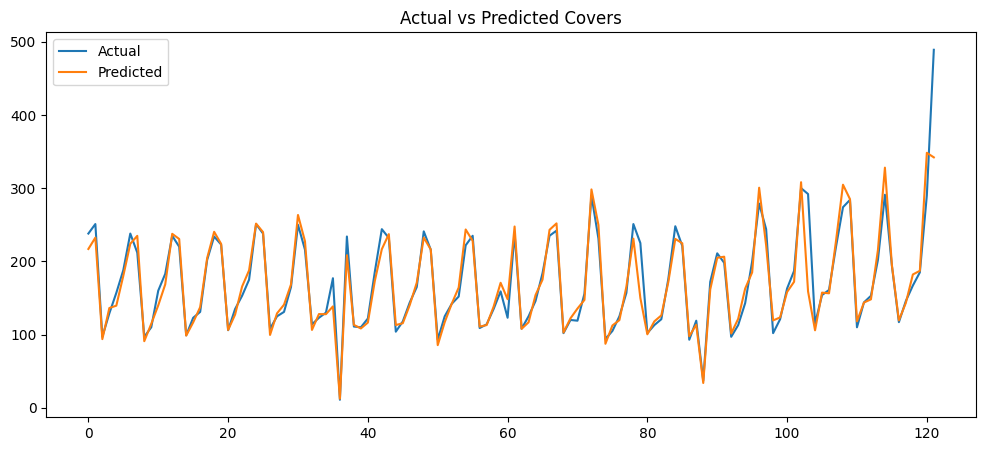

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual')
plt.plot(preds, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Covers")
plt.show()

In [21]:
test['error'] = np.abs(y_test - preds)

dow_error = test.groupby('day_of_week')['error'].mean()

print(dow_error)

day_of_week
1     5.098684
2     4.682605
3     8.417683
4    10.796388
5    17.029564
6    25.420781
Name: error, dtype: float64


/tmp/ipykernel_3052/628106389.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = np.abs(y_test - preds)


In [23]:
drop_cols = ['covers_count', 'avg_check', 'date', 'anomaly_flag', 'notes']

X = df.drop(columns=drop_cols, errors='ignore')

# Keep only numeric
X = X.select_dtypes(include=[np.number])

y = df['avg_check']

In [24]:
X_train = X.iloc[:len(train)]
X_test = X.iloc[len(train):]

y_train = y.iloc[:len(train)]
y_test = y.iloc[len(train):]

In [25]:
model_avg = XGBRegressor(
    n_estimators=300,
    max_depth=5,          # slightly smaller (less variance)
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.2,
    reg_lambda=1,
    random_state=42
)

model_avg.fit(X_train, y_train)

preds_avg = model_avg.predict(X_test)

In [26]:
def wmape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)

mae_avg = np.mean(np.abs(y_test - preds_avg))
wmape_avg = wmape(y_test, preds_avg)
bias_avg = np.mean(preds_avg - y_test)

print("Avg Check Model Performance")
print("MAE:", mae_avg)
print("WMAPE:", wmape_avg)
print("Bias:", bias_avg)

Avg Check Model Performance
MAE: 4.327532956482934
WMAPE: 0.05174972953677633
Bias: 0.30495362078557203


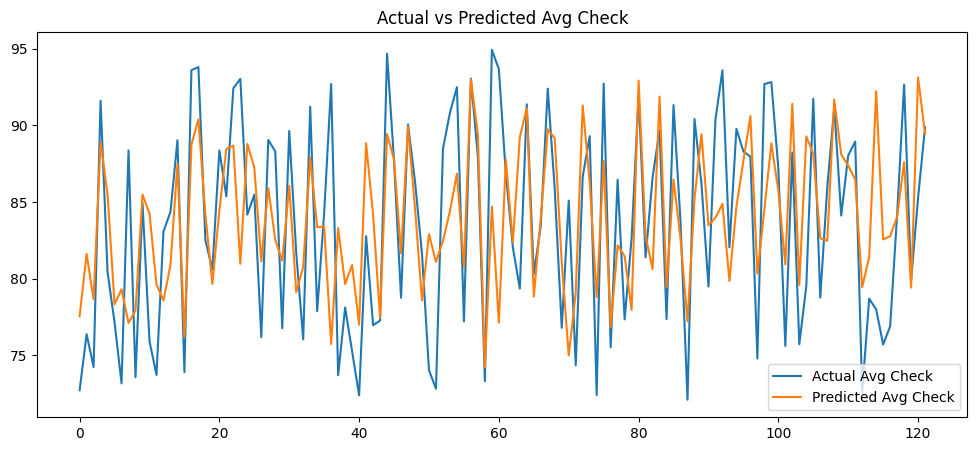

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual Avg Check')
plt.plot(preds_avg, label='Predicted Avg Check')
plt.legend()
plt.title("Actual vs Predicted Avg Check")
plt.show()

In [28]:
importance_avg = pd.Series(model_avg.feature_importances_, index=X_train.columns)
importance_avg.sort_values(ascending=False).head(10)

,0
is_weekend,0.209097
gross_sales,0.126507
day_of_week,0.126090
baseline_pred,0.084473
beverage_sales,0.078036
checks_count,0.068772
food_sales,0.058574
lag_1,0.044816
lag_7,0.044343
month,0.043411


In [29]:
import joblib

joblib.dump(model, "covers_model.pkl")
joblib.dump(model_avg, "avg_check_model.pkl")

['avg_check_model.pkl']

In [30]:

joblib.dump(X_train.columns.tolist(), "features.pkl")

['features.pkl']